In [1]:
# importa as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_excel('Planilha CETESB Dados Cruzados.xlsx', header=4)

primeiro_corpo = dataset.columns[0]
dataset = dataset.rename(columns={dataset.columns[0]: 'Corpo Hidrico'})
dataset.loc[dataset.index[0], 'Corpo Hidrico'] = primeiro_corpo
dataset['Corpo Hidrico'] = dataset['Corpo Hidrico'].ffill()

dataset = dataset[pd.to_datetime(dataset['Data'], errors='coerce').notna()]

colunas_quantitativas = [
    'Temperatura da Água', 'pH', 'Fósforo Total', 'Fósforo-Ortofosfato', 'Sulfato Total',
    'Turbidez', 'Oxigênio Dissolvido', 'Carbono Orgânico Total', 'Carbono Orgânico Dissolvido',
    'Condutividade', 'DBO (5, 20)', 'Sólido Total', 'Sólido Dissolvido Total',
    'Sólido Suspenso Total', 'Nitrogênio Total', 'Nitrogênio Amoniacal', 'Nitrogênio-Nitrato',
    'Nitrogênio Kjeldahl', 'Nitrogênio-Nitrito', 'Clorofila-a', 'Feofitina-a',
    'Escherichia coli**', 'Dureza', 'Sódio', 'Potássio', 'Cobre Total', 'Cloreto Total',
    'Fluoreto Total', 'Níquel Total', 'Bário Total', 'Mercúrio Total', 'Chumbo Total',
    'Ferro Total', 'Ferro Dissolvido', 'Alumínio Total', 'Alumínio Dissolvido', 'Cálcio Total',
    'Cobre Dissolvido', 'Magnésio Total', 'Boro Total', 'Cádmio Total', 'Crômio Total',
    'Manganês Total', 'Zinco Total', 'Subst. Tensoat. reagem c/ Azul Metileno',
    'Gadolínio antrópico',
]

# ATENÇÃO: aqui o '<' e o '>' são removidos e o número vira medição. Valores como
# '<0,0002' estão abaixo do limite de quantificação (censurados): o número é o limite
# do método, não uma medição real. Isso afeta muito Mercúrio, Cádmio e Cobre Dissolvido
# (mais de 85% dos valores têm '<'). Mantemos assim por simplicidade, mas os outliers
# dessas variáveis devem ser lidos com cautela.
for coluna in colunas_quantitativas:
    dataset[coluna] = pd.to_numeric(dataset[coluna].astype(str).str.replace('<', '', regex=False).str.replace('>', '', regex=False).str.replace(',', '.', regex=False), errors='coerce')

# Separa em uma tabela por ponto de monitoramento
dataset_pontos = {ponto: grupo.reset_index(drop=True) for ponto, grupo in dataset.groupby('Ponto')}

In [3]:
# faz conferências básicas
print(dataset.shape)
print()
print(dataset.head())

(753, 54)

              Corpo Hidrico   Ano       Mês      Ponto                 Data  \
0  BARRA BONITA - RIO TIETÊ  2014   janeiro  TIBB02100  2014-01-21 00:00:00   
1  BARRA BONITA - RIO TIETÊ   NaN     março  TIBB02100  2014-03-18 00:00:00   
2  BARRA BONITA - RIO TIETÊ   NaN      maio  TIBB02100  2014-05-13 00:00:00   
3  BARRA BONITA - RIO TIETÊ   NaN     julho  TIBB02100  2014-07-15 00:00:00   
4  BARRA BONITA - RIO TIETÊ   NaN  setembro  TIBB02100  2014-09-30 00:00:00   

   Temperatura da Água    pH  Fósforo Total  Fósforo-Ortofosfato  \
0                29.17  8.47           0.31                  NaN   
1                29.74  9.44           0.50                  NaN   
2                23.50  7.34           0.12                  NaN   
3                20.19  7.28           0.19                  NaN   
4                22.97  7.12           0.77                  NaN   

   Sulfato Total  ...  Boro Total  Cádmio Total  Crômio Total  Manganês Total  \
0            NaN  ...   

In [4]:
pontos = ['PCAB02300', 'PCAB02800', 'PCBP02500', 'TIBB02100', 'TIBB02700',
          'TIBT02500', 'TIET02500', 'TIET02600', 'TIET02700', 'TIET02900',
          'TIPR02400', 'TIPR02990', 'TITR02100', 'TITR02800']

for ponto in pontos:
    print(f"====================== TABELA DO PONTO {ponto} ======================\n")
    print(dataset_pontos[ponto].head())
    print()

====================== TABELA DO PONTO PCAB02300 ======================

                   Corpo Hidrico   Ano       Mês      Ponto  \
0  BARRA BONITA - RIO PIRACICABA  2014   janeiro  PCAB02300   
1  BARRA BONITA - RIO PIRACICABA   NaN     março  PCAB02300   
2  BARRA BONITA - RIO PIRACICABA   NaN      maio  PCAB02300   
3  BARRA BONITA - RIO PIRACICABA   NaN     julho  PCAB02300   
4  BARRA BONITA - RIO PIRACICABA   NaN  setembro  PCAB02300   

                  Data  Temperatura da Água   pH  Fósforo Total  \
0  2014-01-14 00:00:00                 27.3  7.6            0.5   
1  2014-03-12 00:00:00                 26.8  7.4            0.4   
2  2014-05-13 00:00:00                 22.7  7.6            1.0   
3  2014-07-15 00:00:00                 21.0  7.4            0.9   
4  2014-09-09 00:00:00                 22.9  7.5            0.8   

   Fósforo-Ortofosfato  Sulfato Total  ...  Boro Total  Cádmio Total  \
0                  NaN            NaN  ...         NaN         0.001   
1

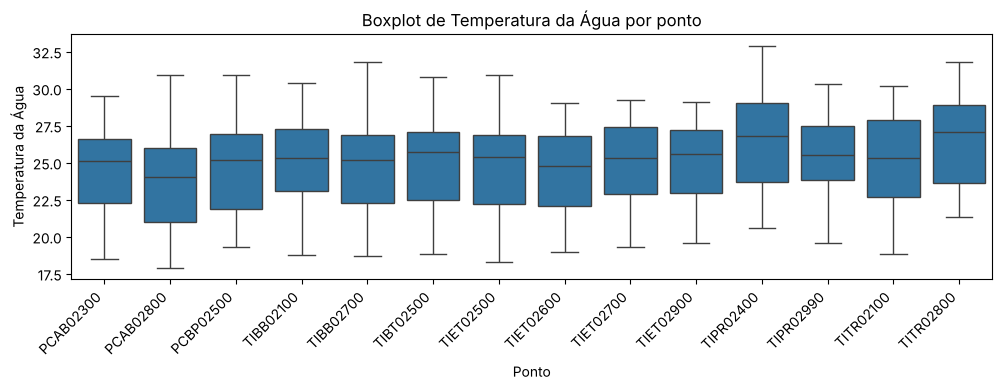

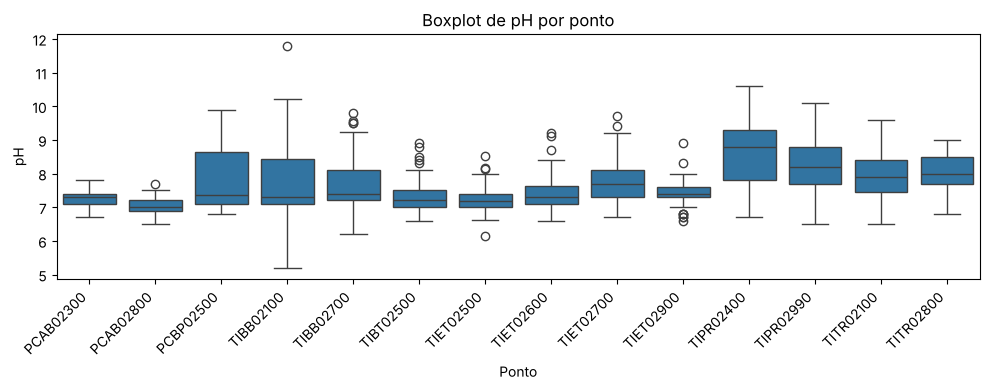

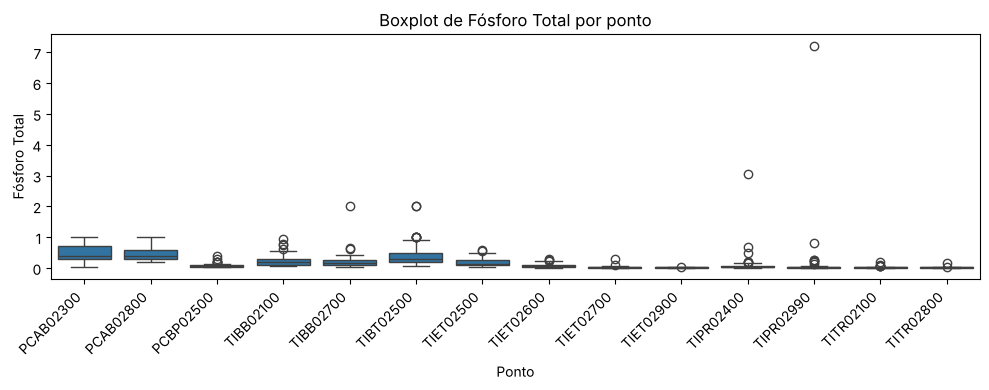

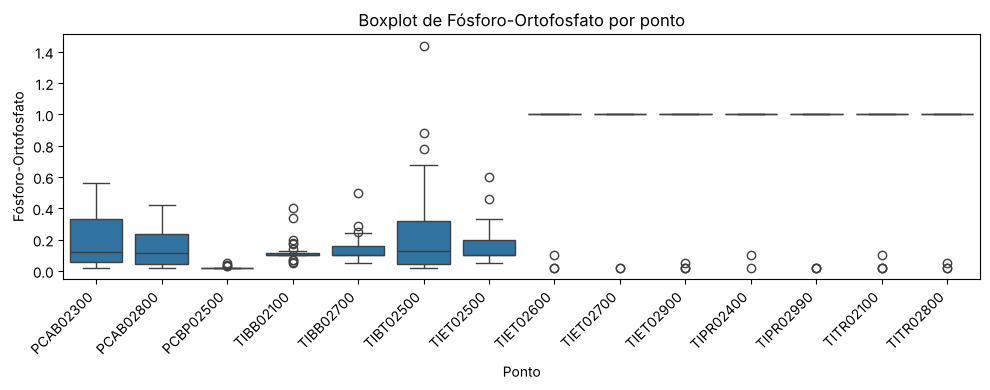

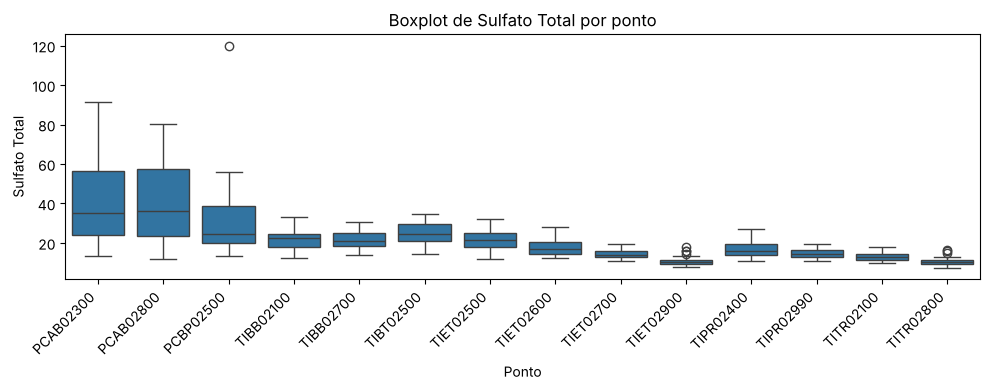

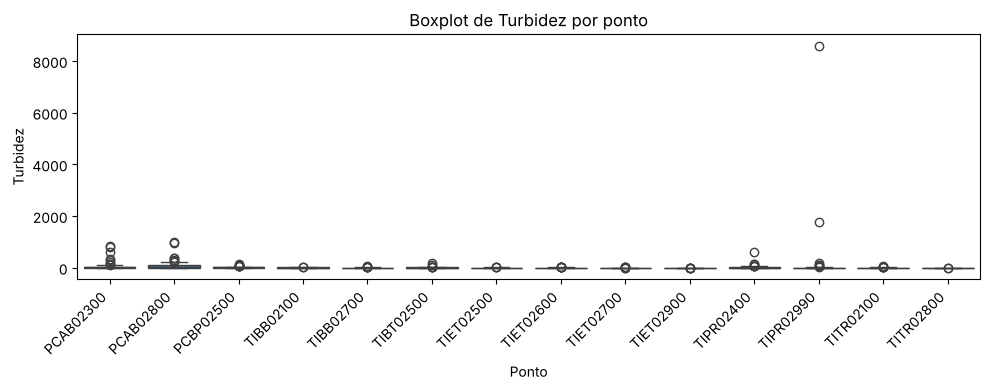

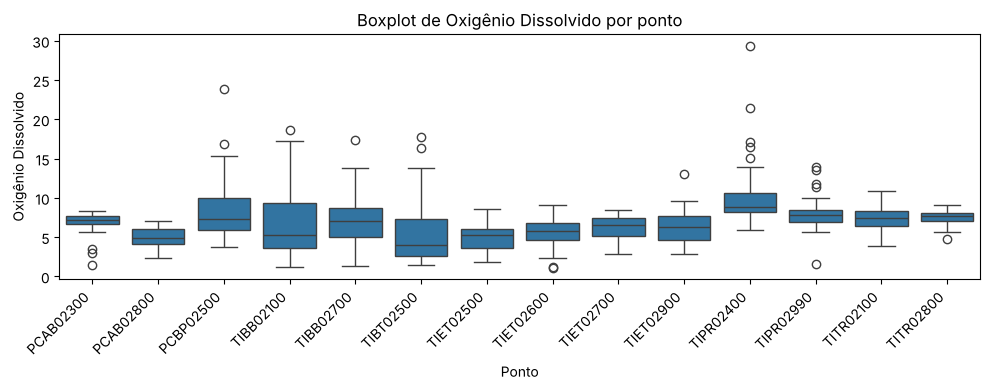

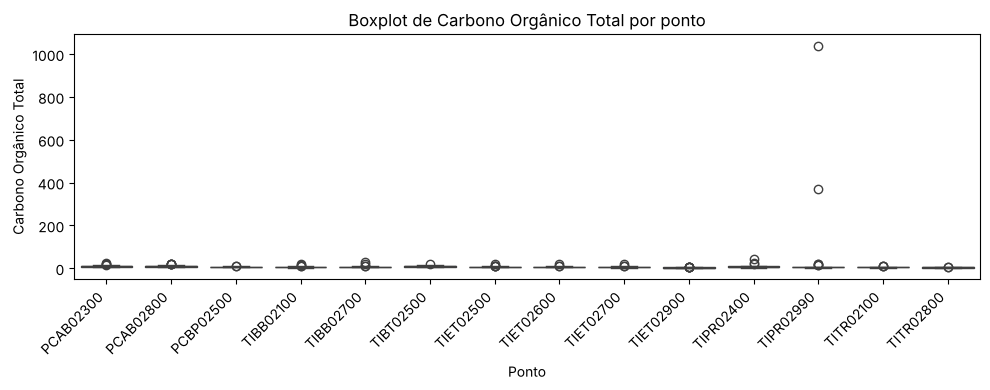

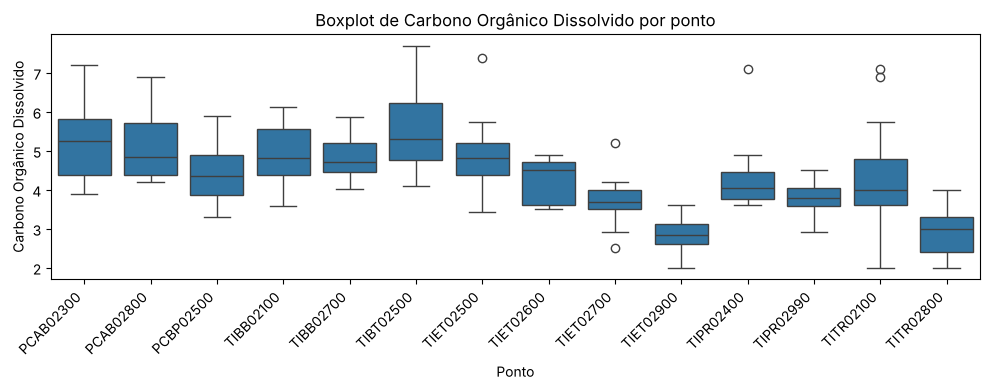

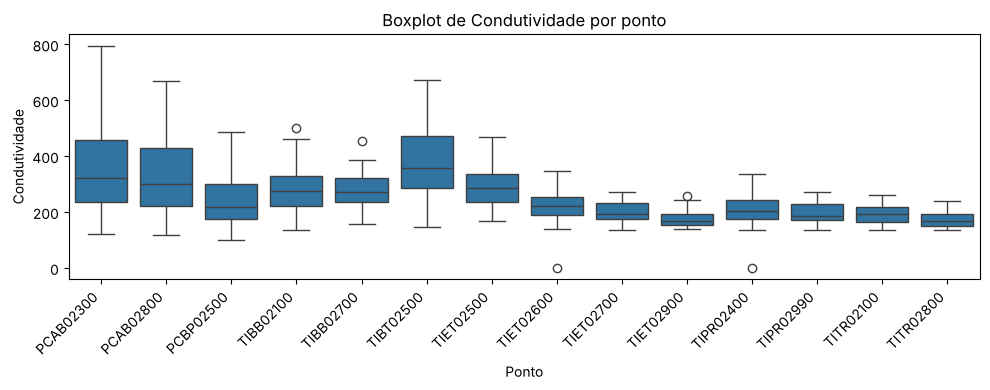

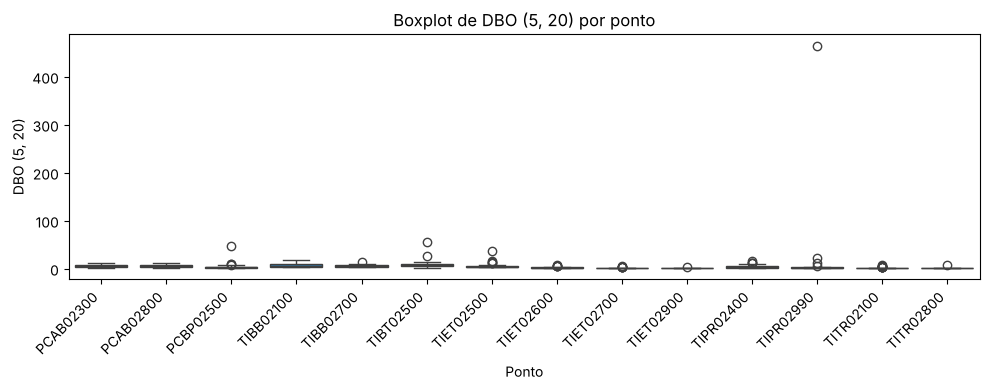

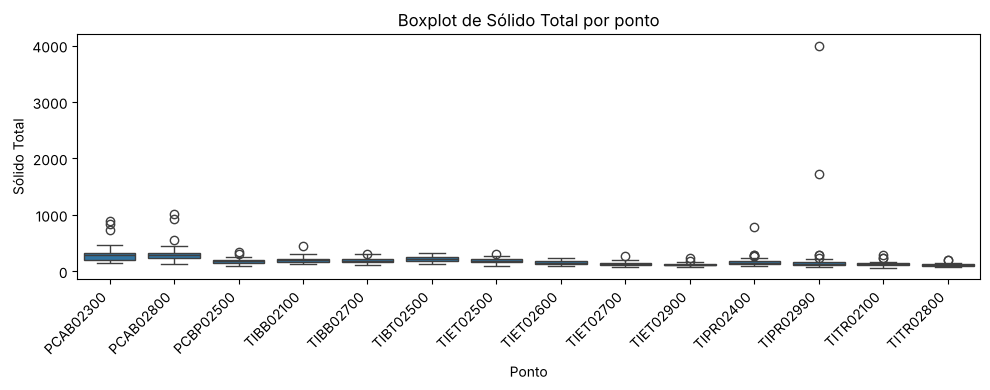

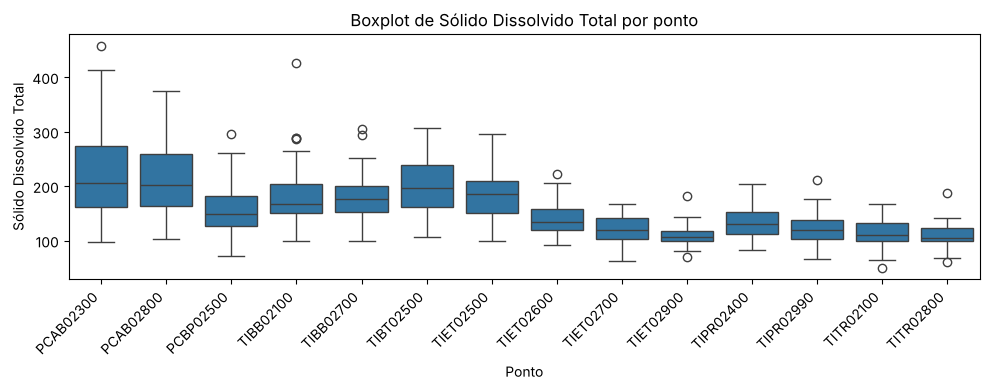

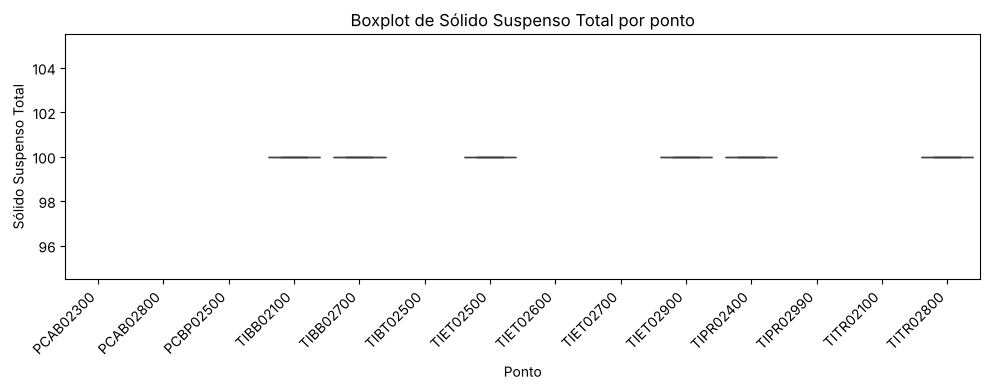

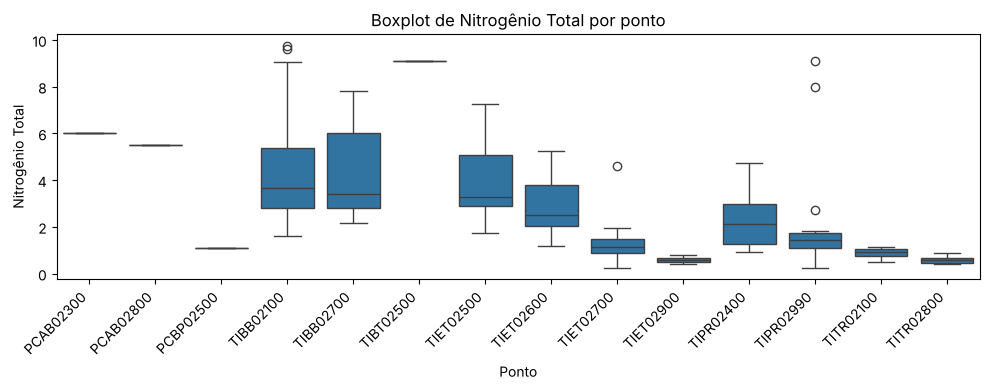

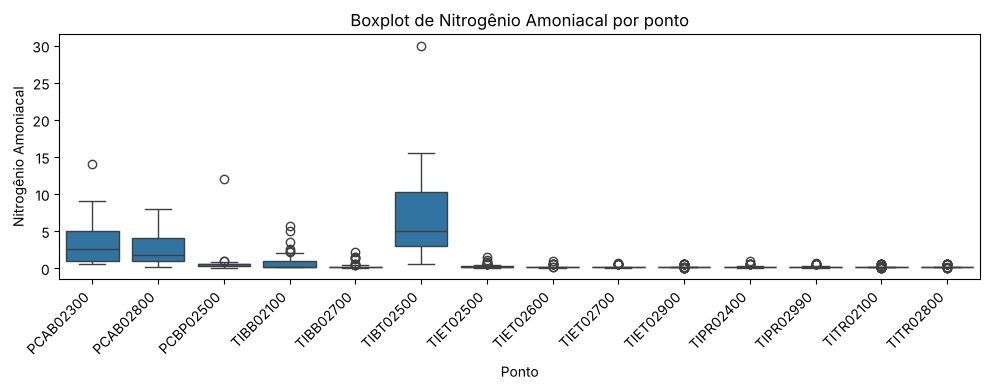

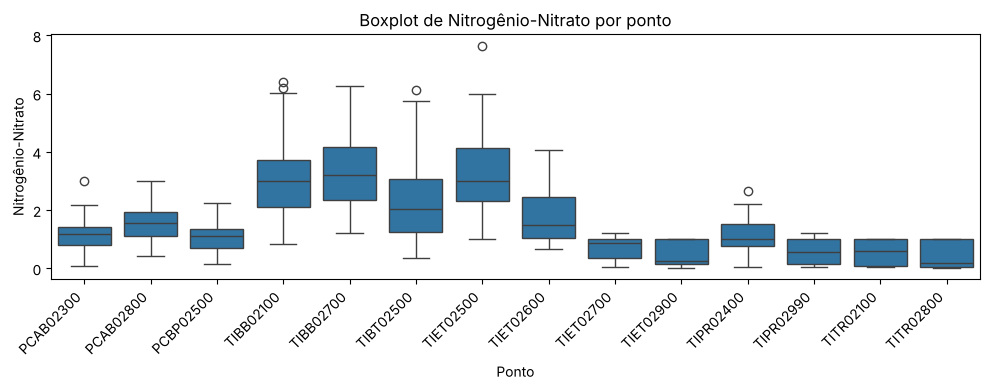

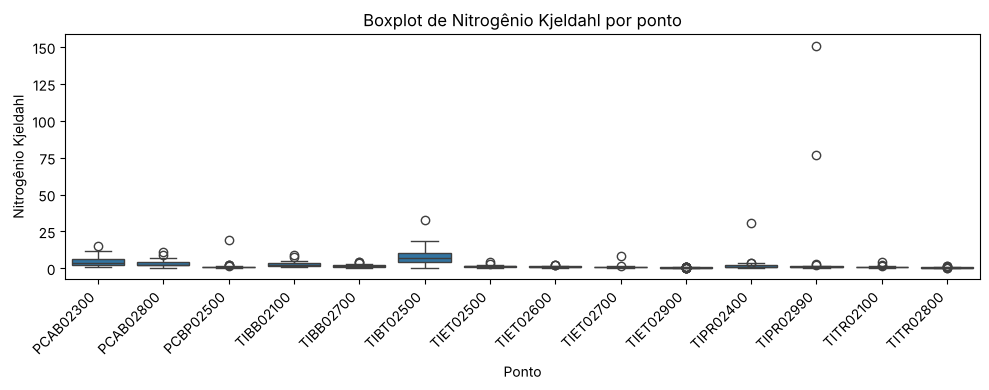

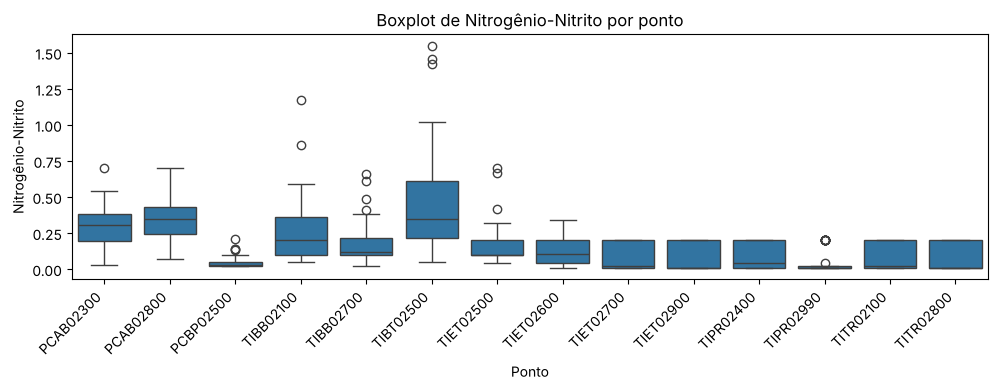

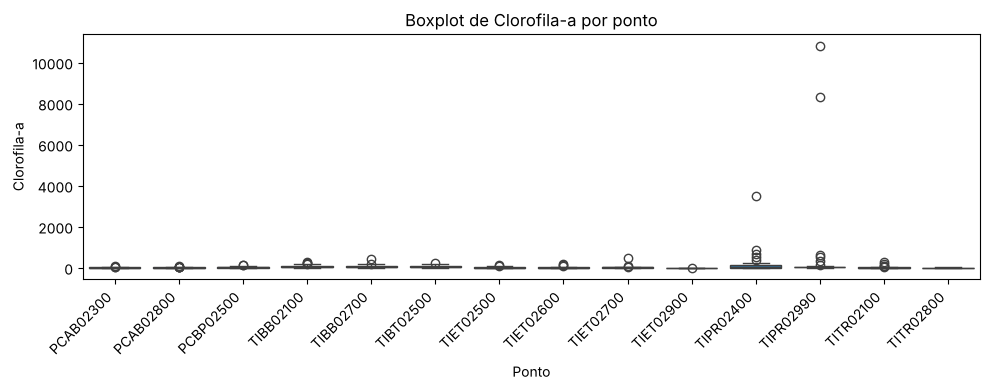

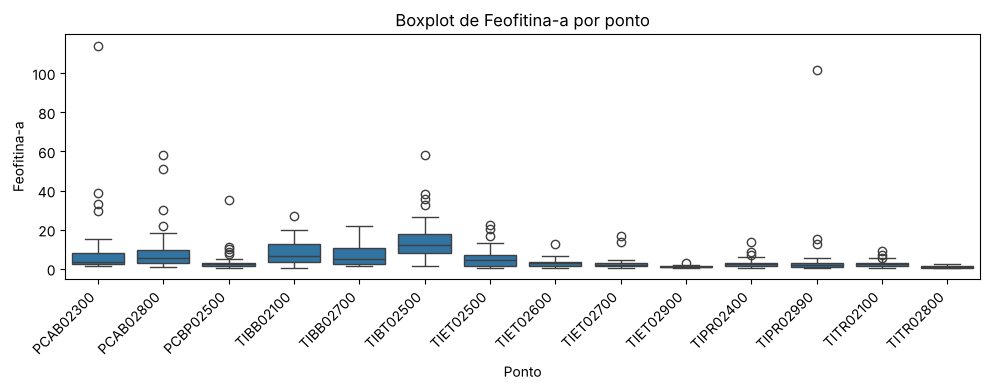

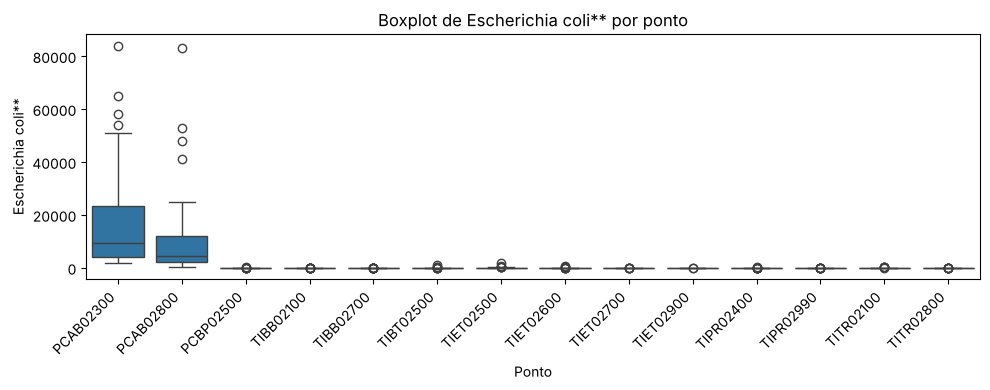

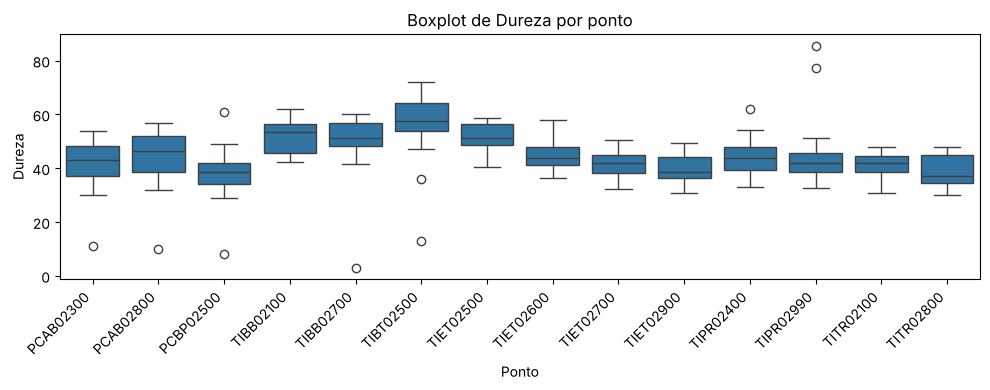

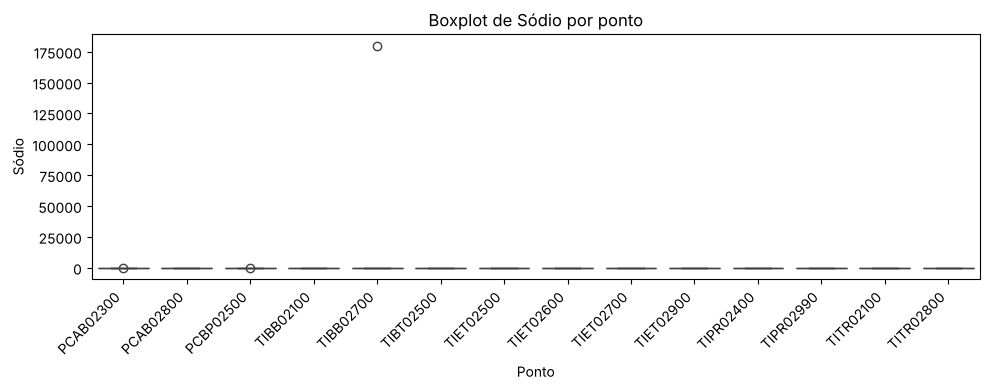

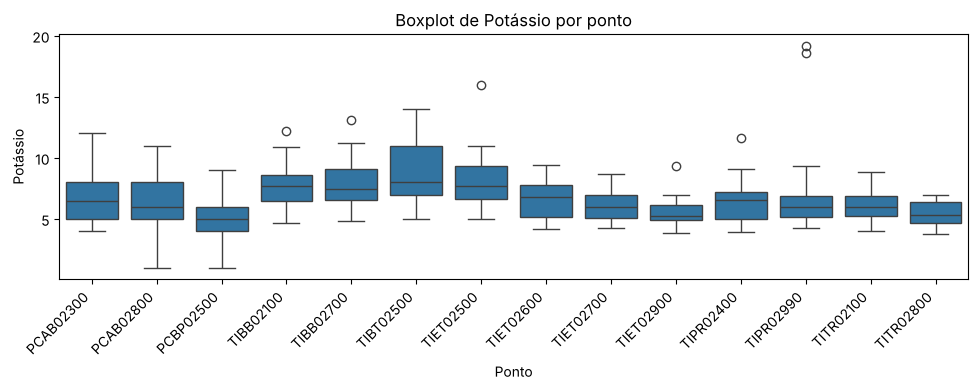

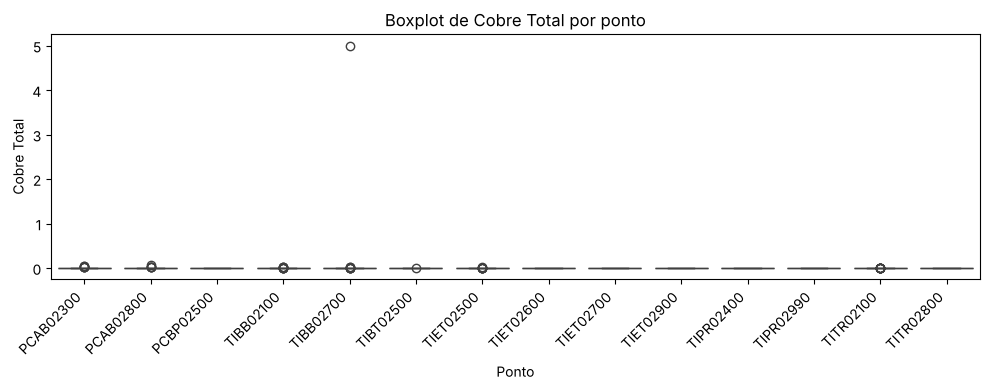

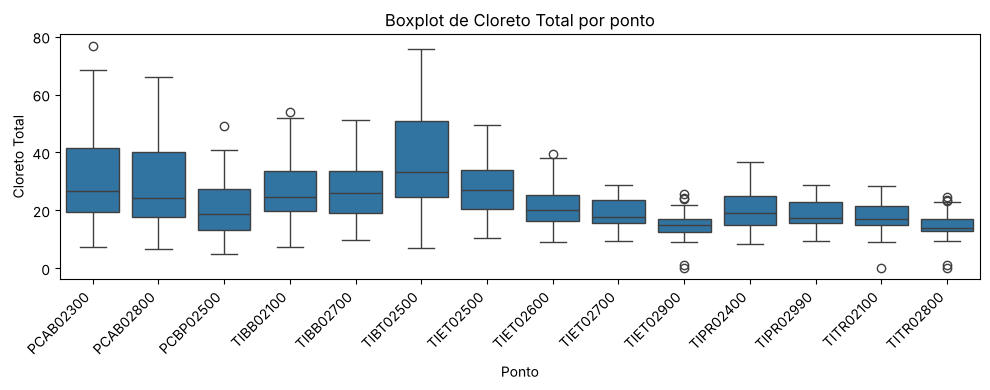

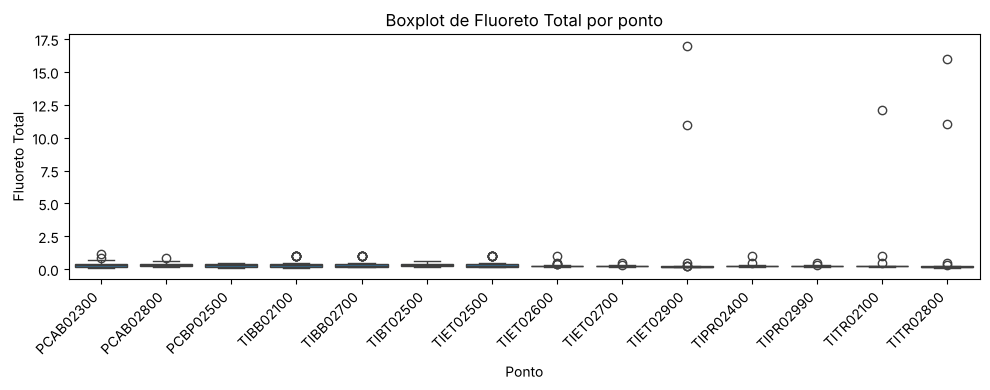

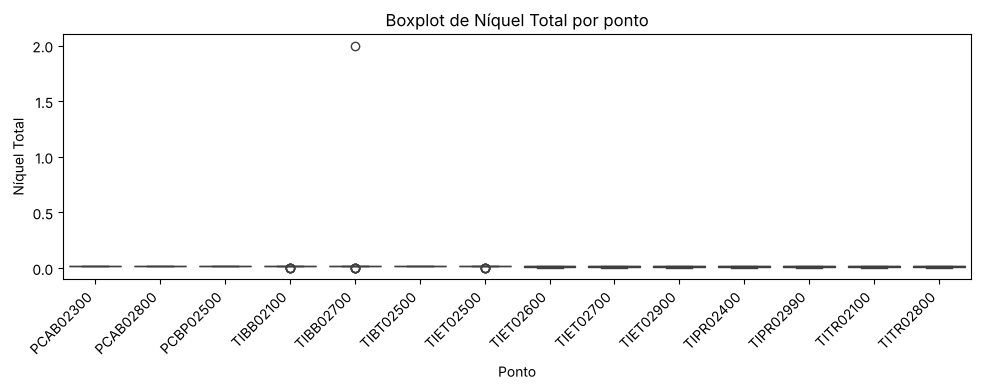

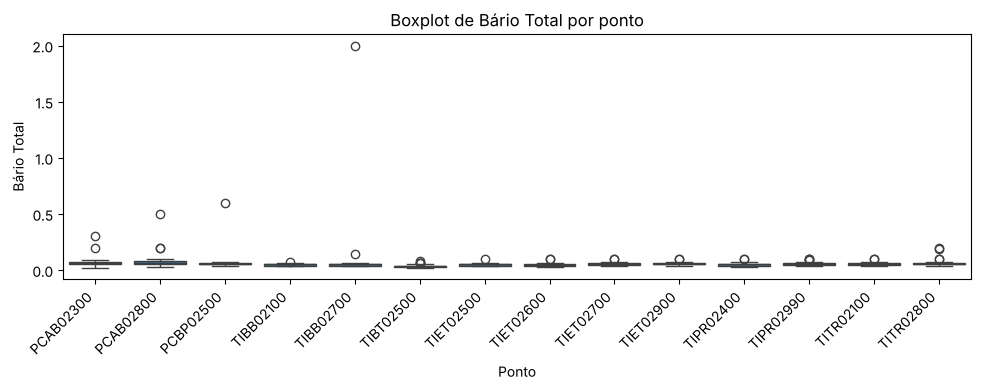

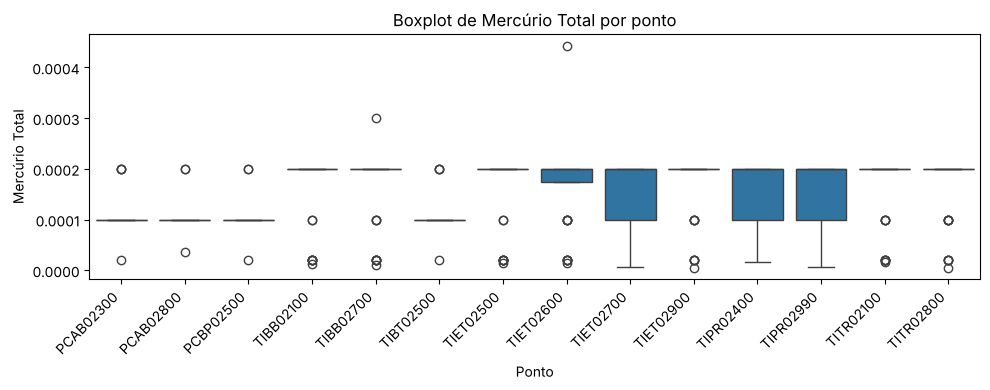

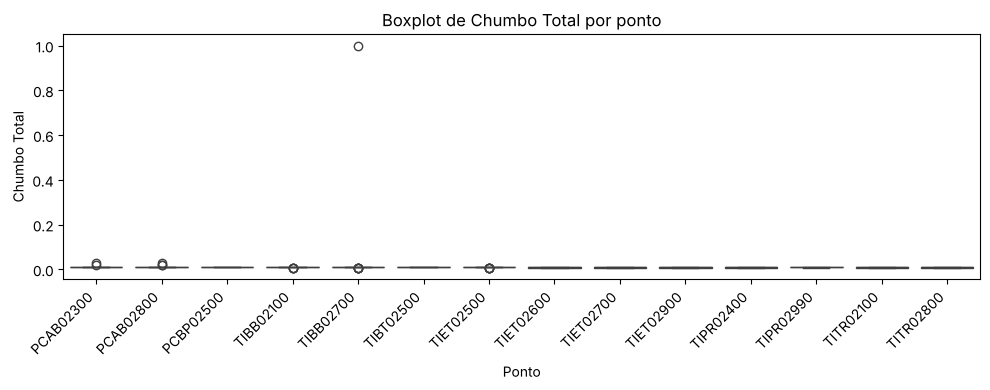

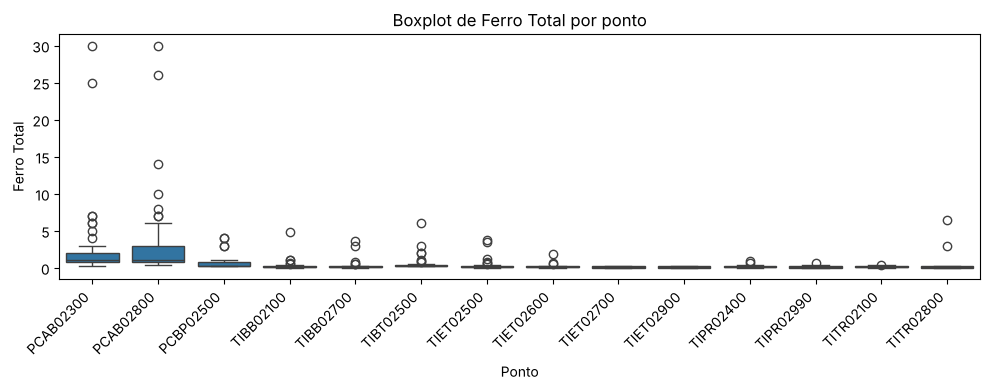

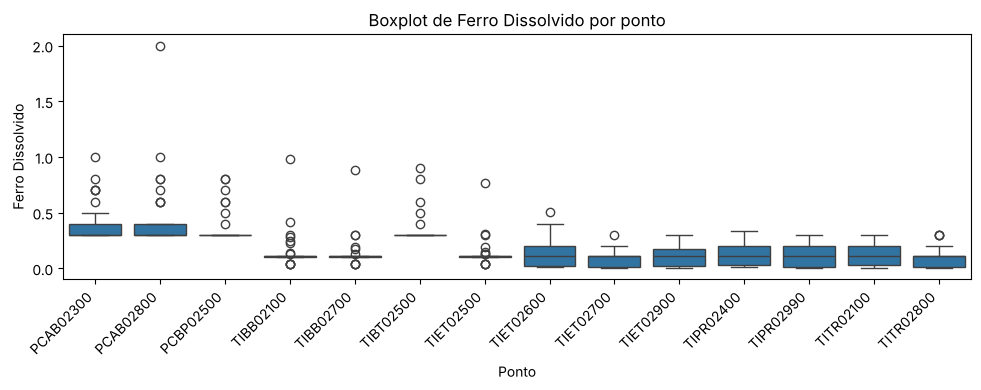

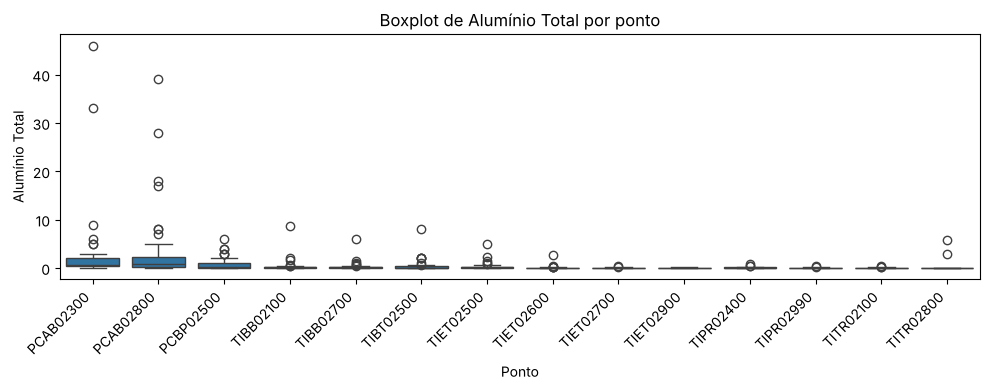

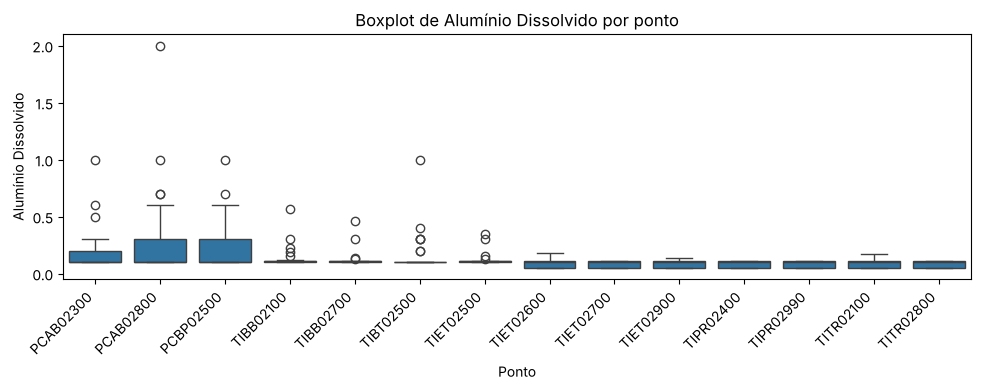

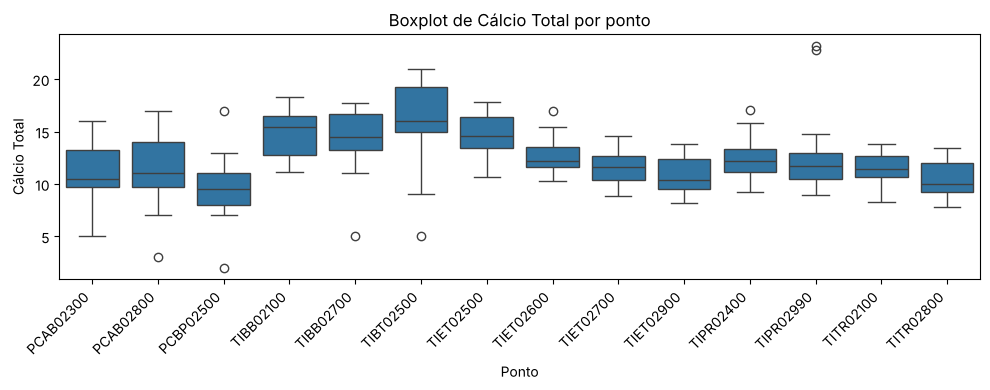

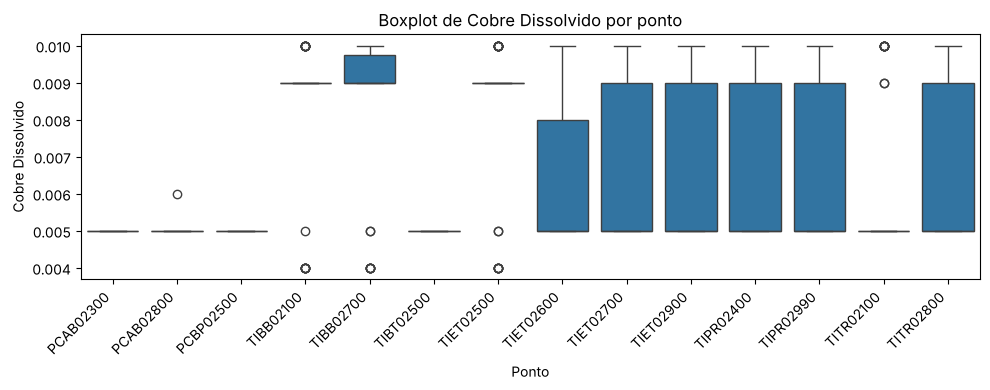

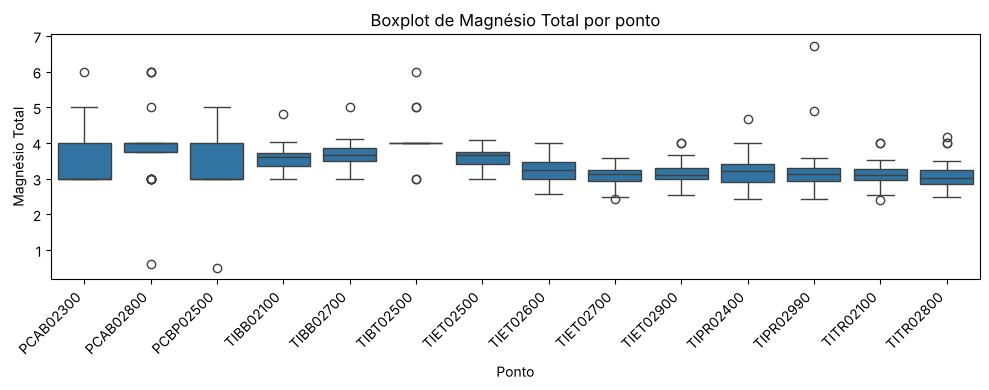

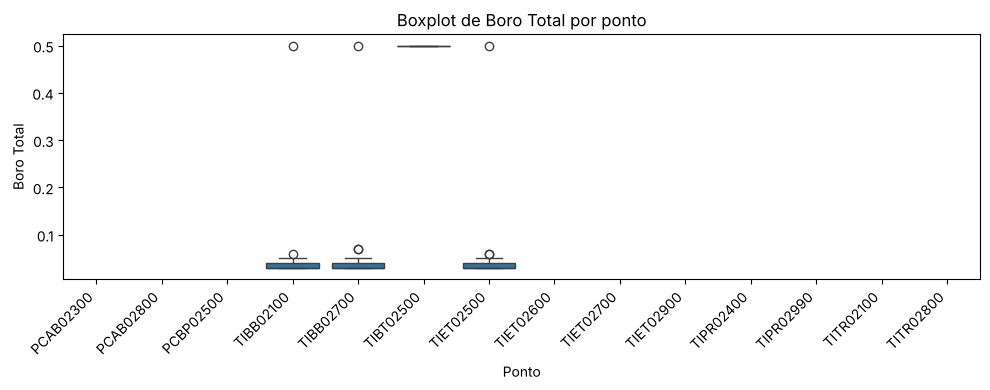

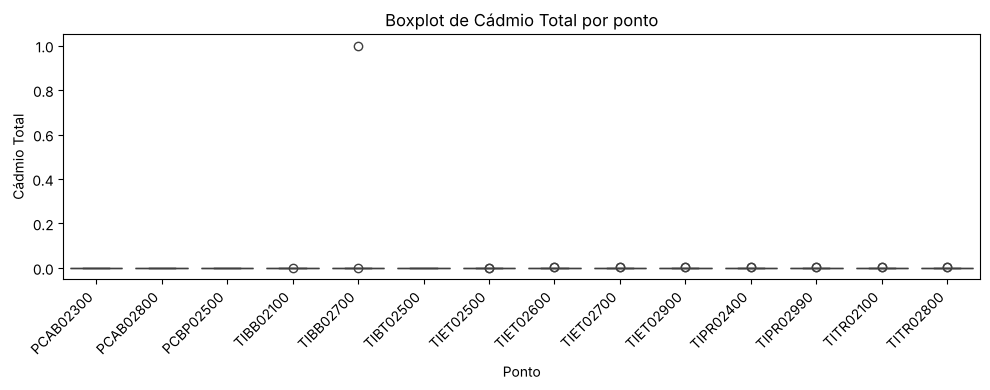

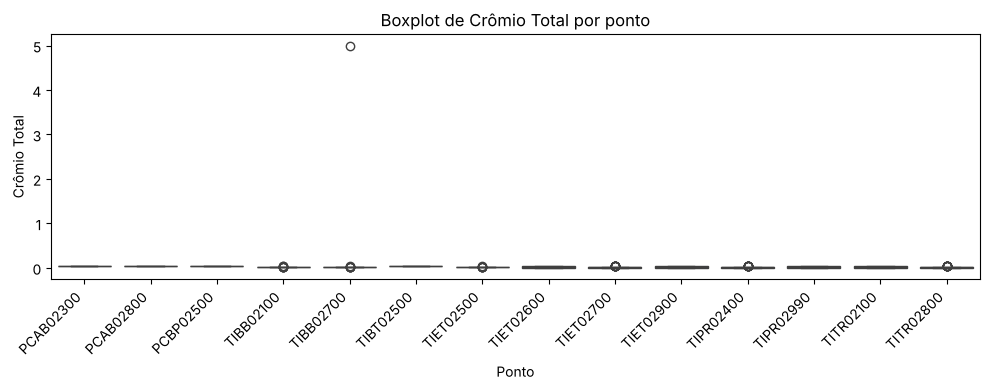

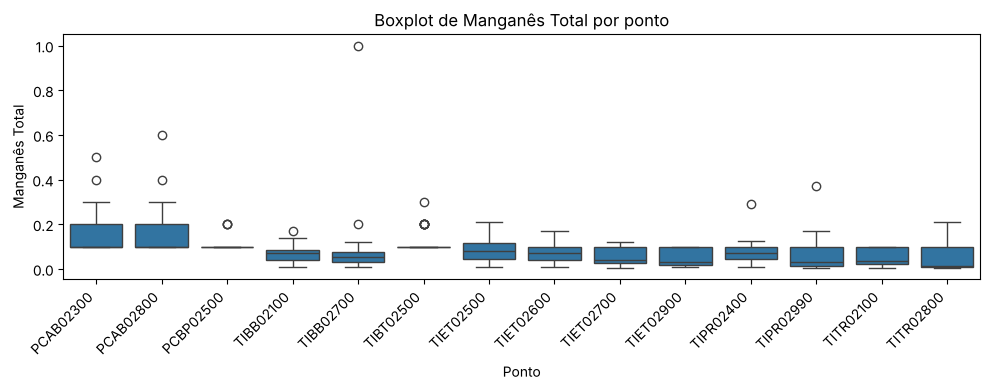

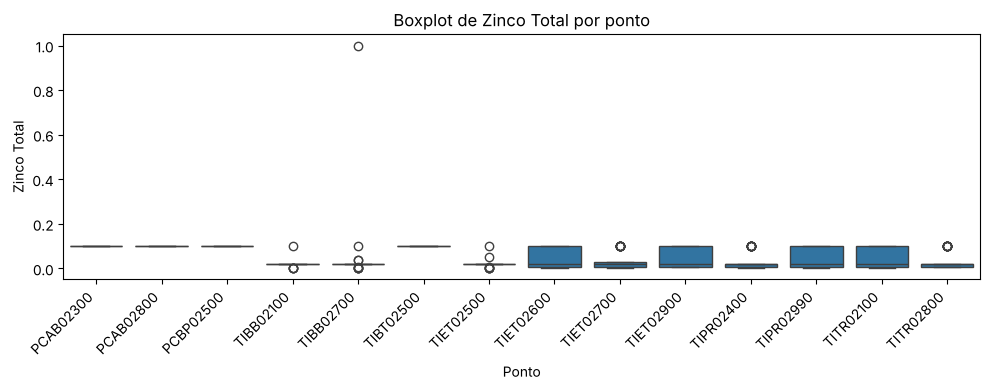

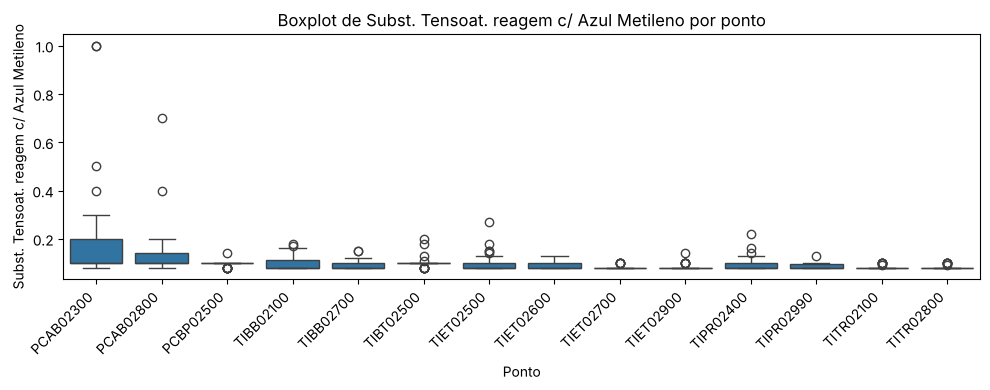

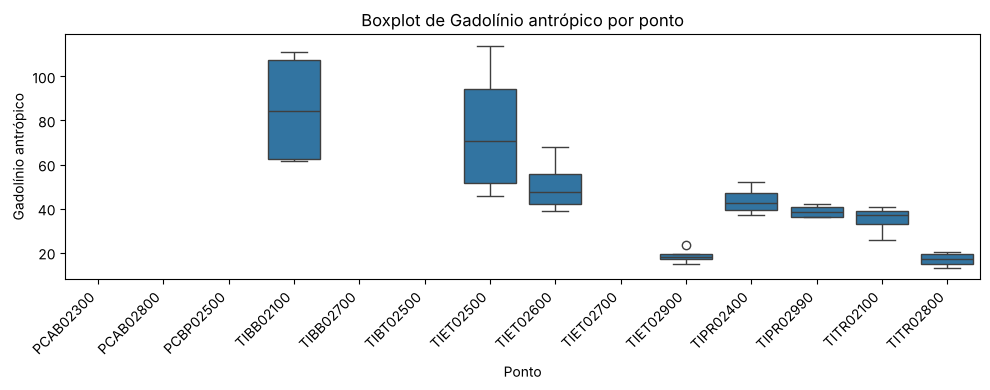

In [5]:
def plota_boxplot(coluna):
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=dataset, x="Ponto", y=coluna, order=pontos)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Boxplot de {coluna} por ponto")
    plt.tight_layout()
    plt.show()

for coluna in colunas_quantitativas:
    plota_boxplot(coluna)

In [6]:
# colunas com pelo menos 95% de preenchimento
preenchimento = dataset[colunas_quantitativas].notna().mean()
colunas_obrigatorias = preenchimento[preenchimento >= 0.95].index.tolist()

print(f"{len(colunas_obrigatorias)} de {len(colunas_quantitativas)} colunas com >= 95% preenchidas:")
print(preenchimento[colunas_obrigatorias].sort_values(ascending=False).round(3))

14 de 46 colunas com >= 95% preenchidas:
Oxigênio Dissolvido        1.000
Temperatura da Água        0.999
Condutividade              0.997
Carbono Orgânico Total     0.996
Cloreto Total              0.992
pH                         0.992
Nitrogênio-Nitrito         0.992
Nitrogênio-Nitrato         0.992
Escherichia coli**         0.991
Sólido Total               0.989
Sólido Dissolvido Total    0.989
Turbidez                   0.988
Fósforo Total              0.988
Nitrogênio Amoniacal       0.967
dtype: float64


In [7]:
# ridgeline: uma densidade por ponto, empilhadas na mesma escala, para comparar ponto a ponto.
# Usa escala log10 quando a variável é positiva e bem assimétrica (skew > 1); senão, escala original.
def ridgelines(coluna, sobreposicao=0.6):
    dados = dataset[["Ponto", coluna]].dropna()
    usar_log = (dados[coluna] > 0).all() and dados[coluna].skew() > 1
    if usar_log:
        dados = dados.assign(valor=np.log10(dados[coluna]))
    else:
        dados = dados.assign(valor=dados[coluna])

    # ordena os pontos pela mediana, para o ridgeline ficar legível
    ordem = dados.groupby("Ponto")["valor"].median().sort_values().index.tolist()
    xmin, xmax = dados["valor"].min(), dados["valor"].max()
    margem = (xmax - xmin) * 0.05 or 1
    cores = sns.color_palette("viridis", len(ordem))

    fig, axes = plt.subplots(len(ordem), 1, figsize=(10, 0.7 * len(ordem) + 1.5), sharex=True)
    for ax, ponto, cor in zip(axes, ordem, cores):
        valores = dados.loc[dados["Ponto"] == ponto, "valor"]
        if valores.nunique() > 1:
            sns.kdeplot(x=valores, ax=ax, fill=True, color=cor, alpha=0.8, linewidth=1, clip=(xmin, xmax))
        ax.axvline(valores.median(), color="black", linewidth=0.8)
        ax.set_xlim(xmin - margem, xmax + margem)
        ax.set_yticks([])
        ax.set_ylabel(ponto, rotation=0, ha="right", va="center", fontsize=8)
        ax.patch.set_alpha(0)
        for lado in ("top", "right", "left"):
            ax.spines[lado].set_visible(False)
        if ax is not axes[-1]:
            ax.spines["bottom"].set_visible(False)
            ax.tick_params(bottom=False)
    fig.subplots_adjust(hspace=-sobreposicao)
    escala = "log10 de " if usar_log else ""
    axes[-1].set_xlabel(f"{escala}{coluna}")
    fig.suptitle(f"Ridgeline de {coluna} por ponto (linha preta = mediana)", y=0.98)
    plt.show()

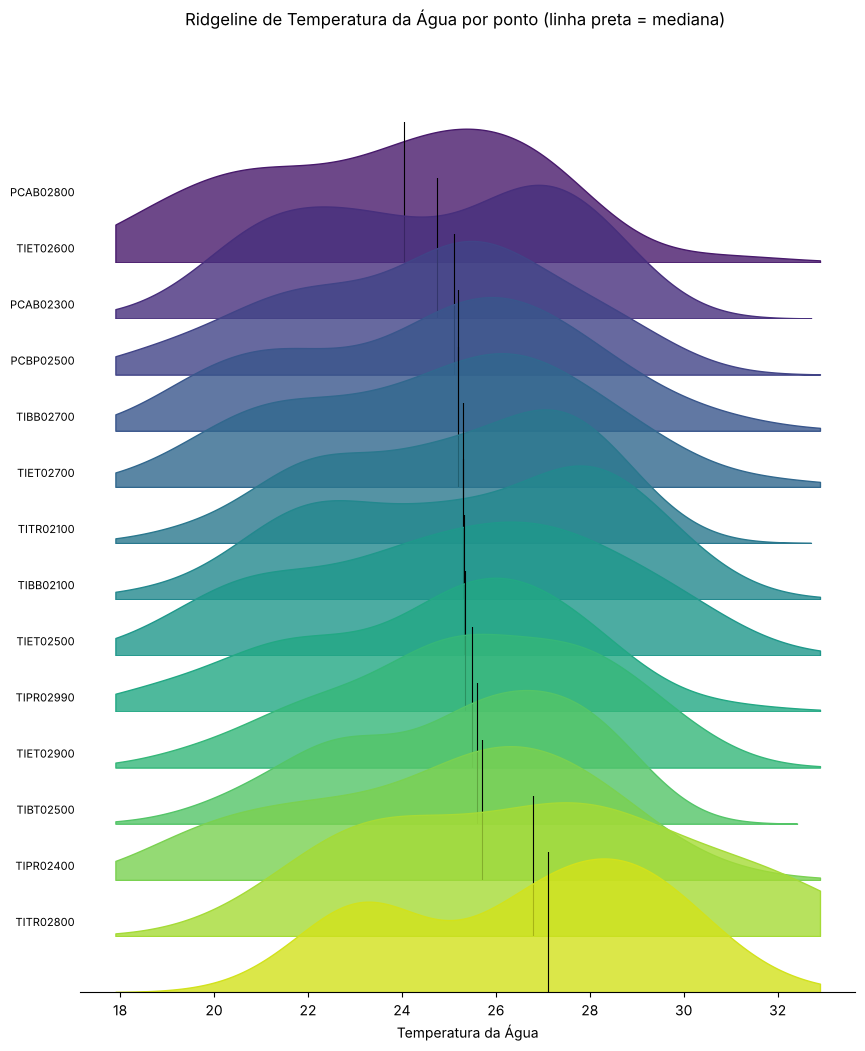

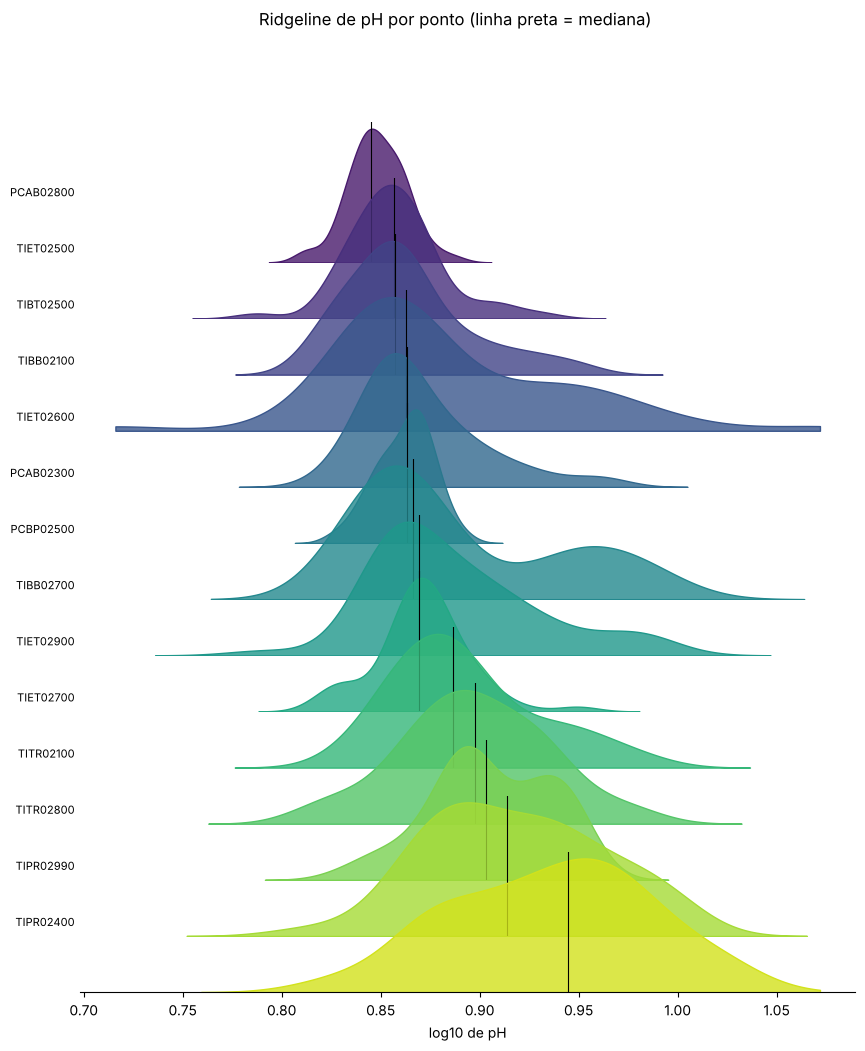

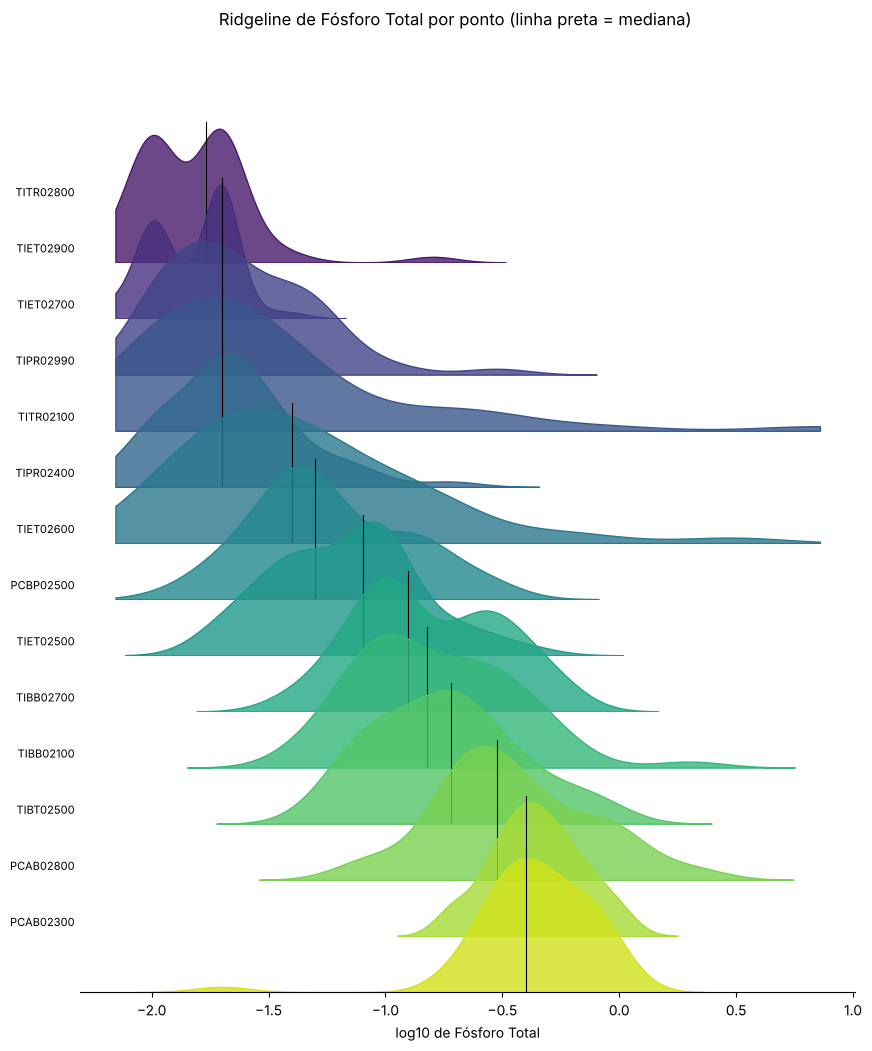

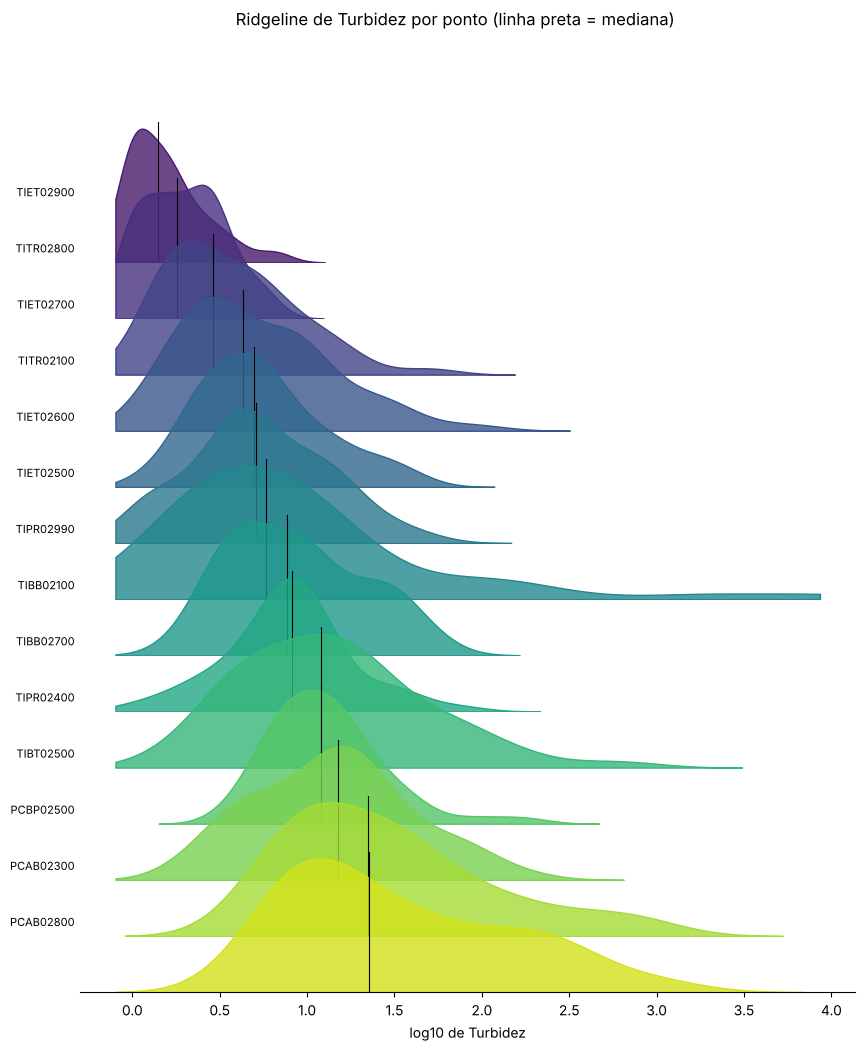

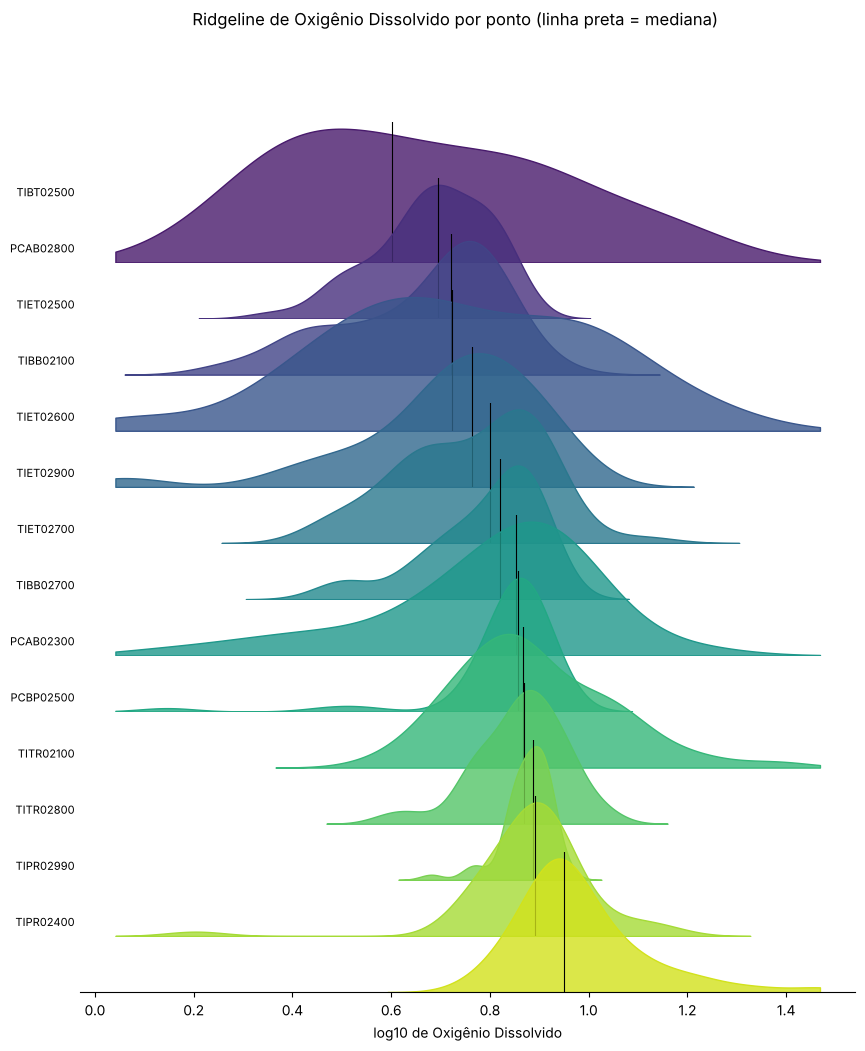

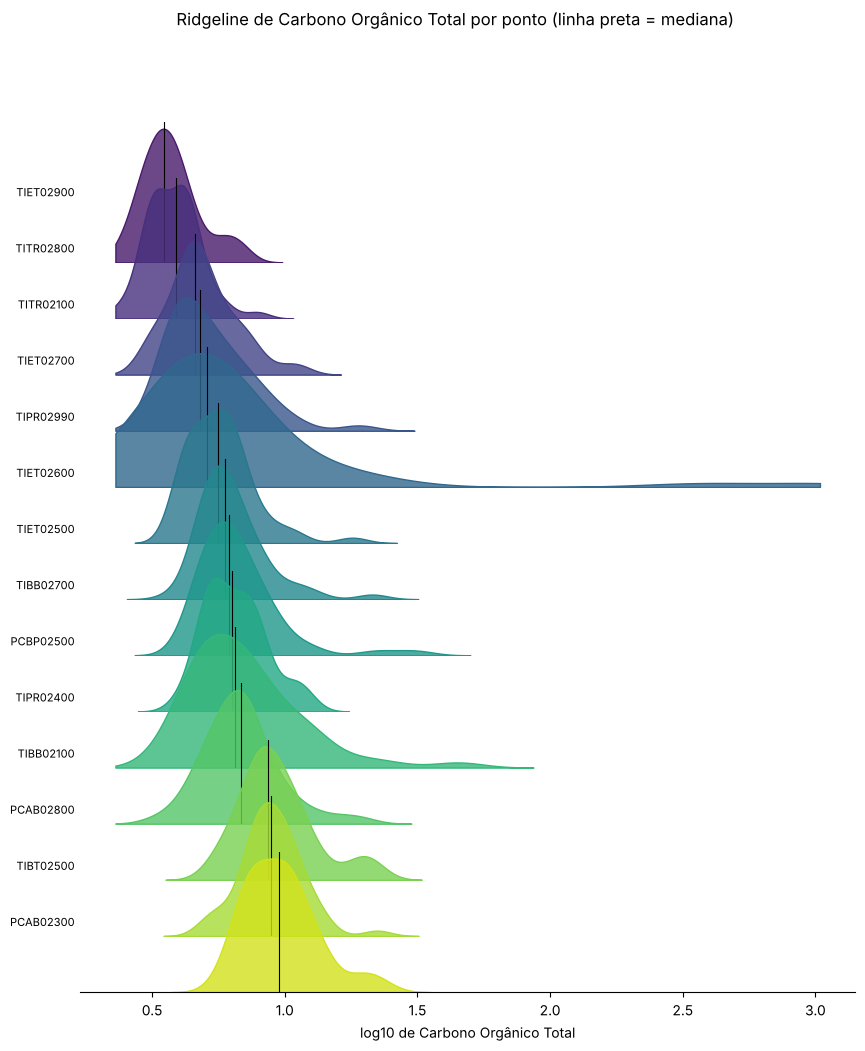

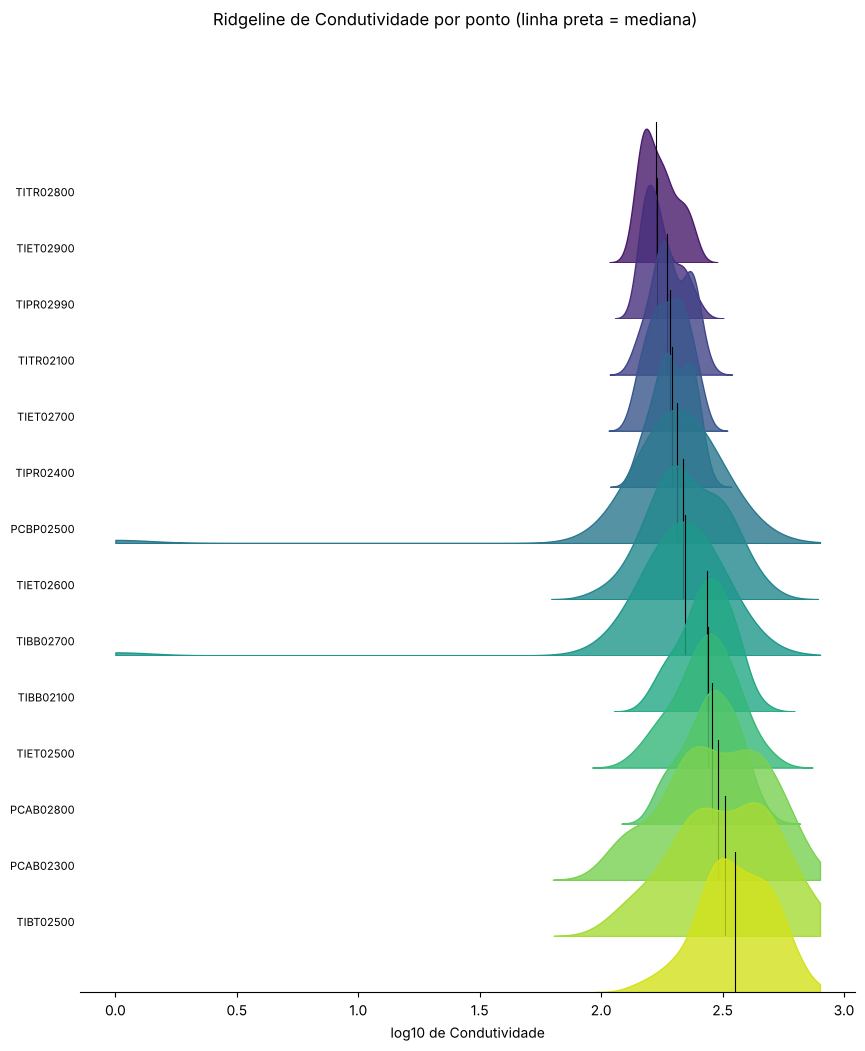

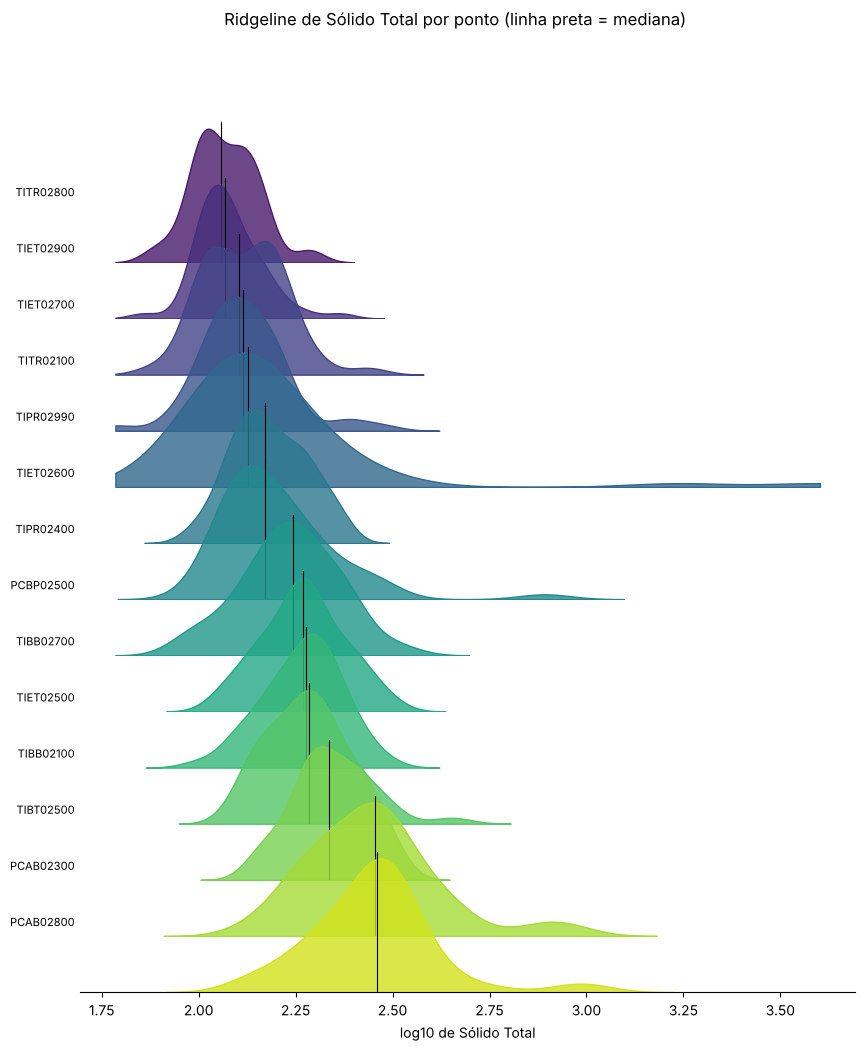

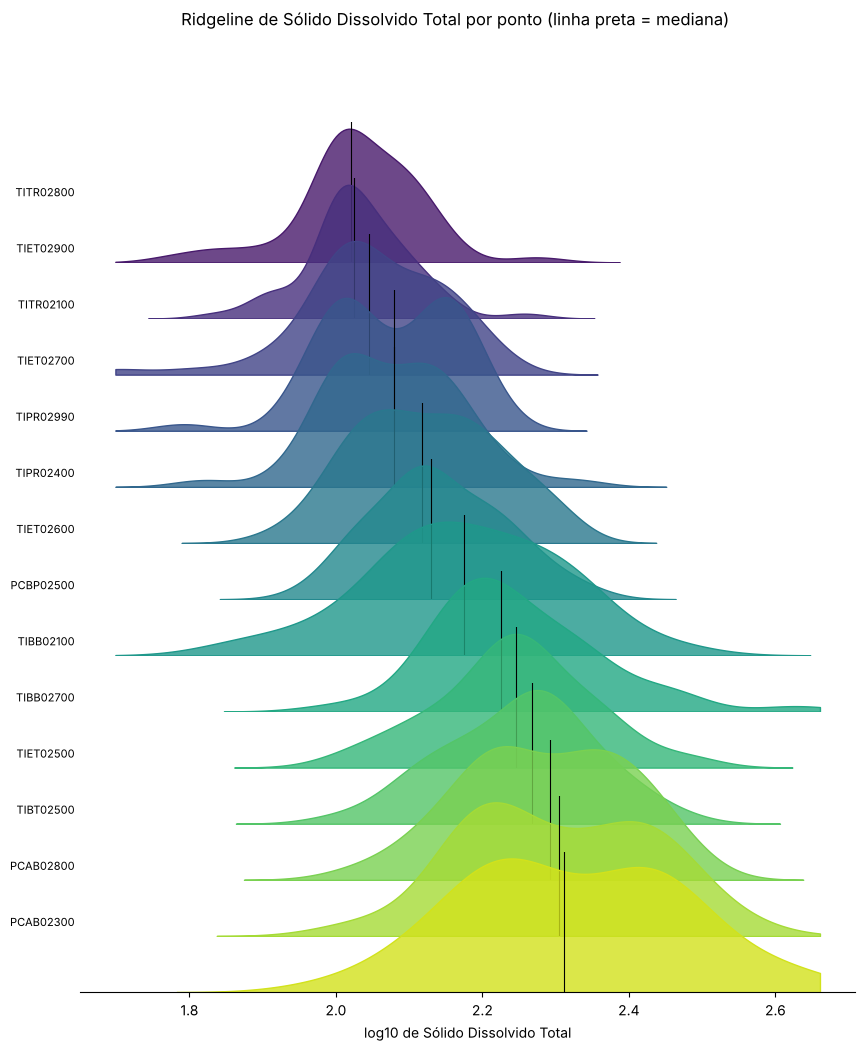

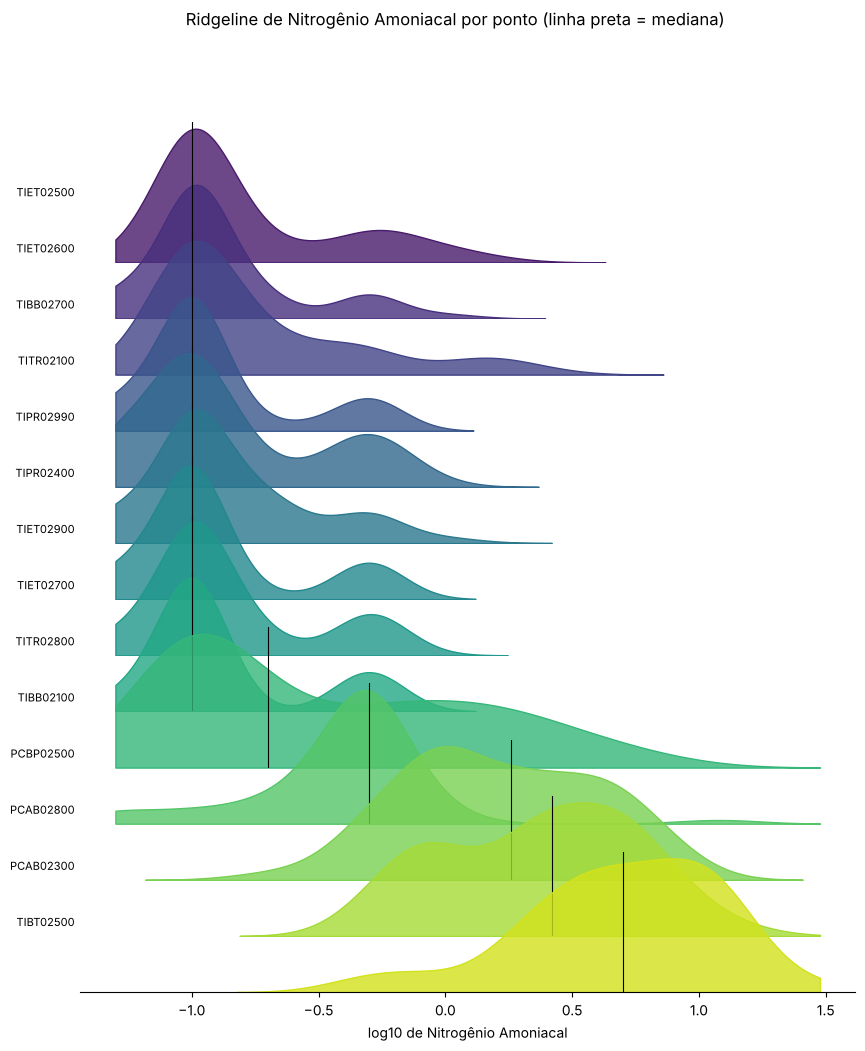

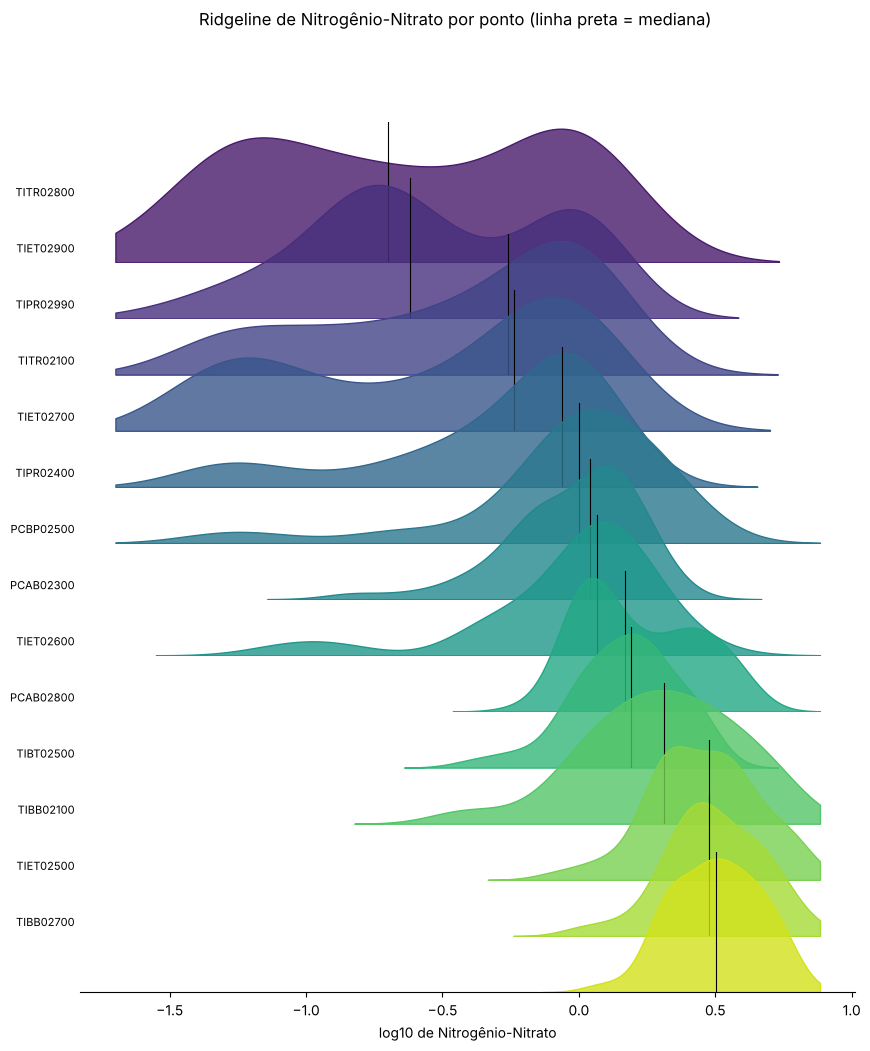

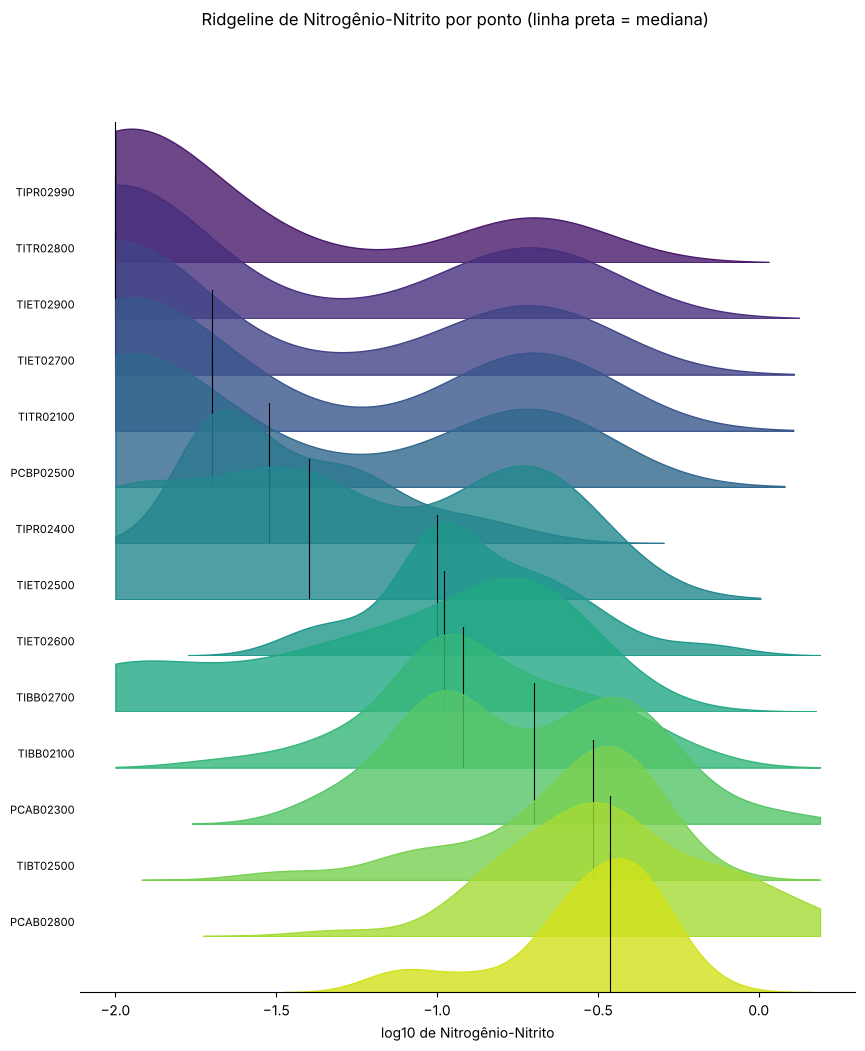

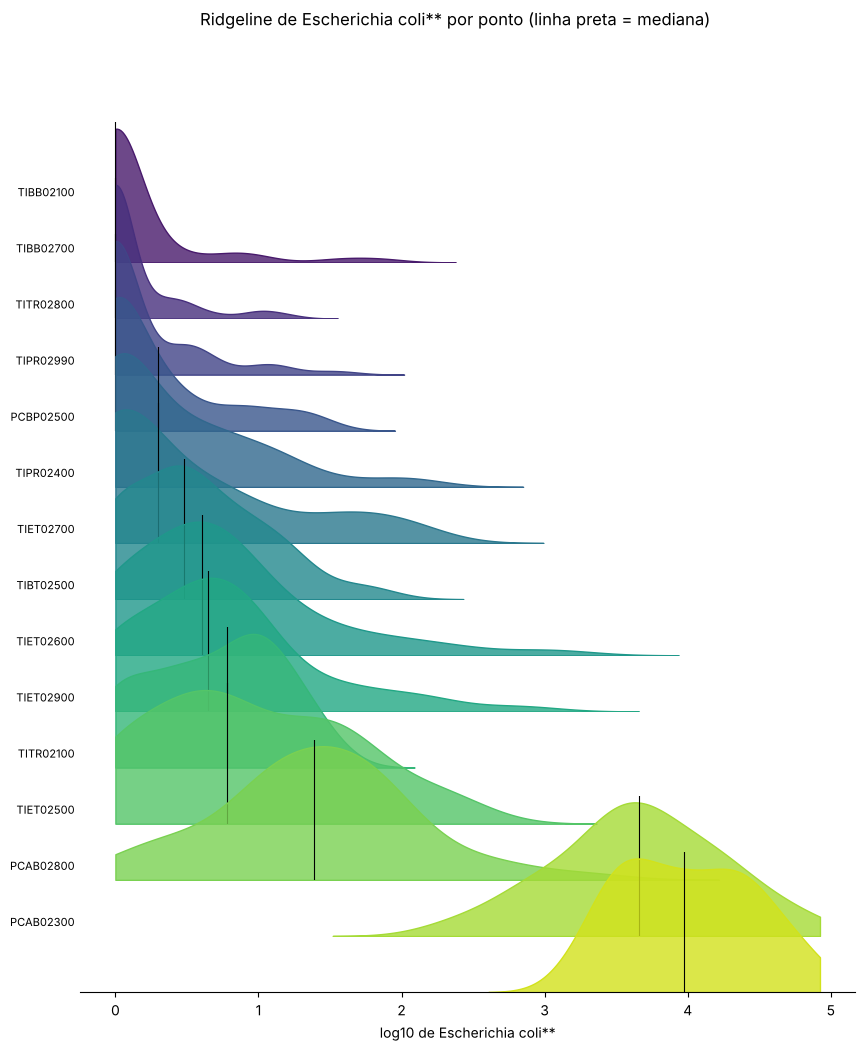

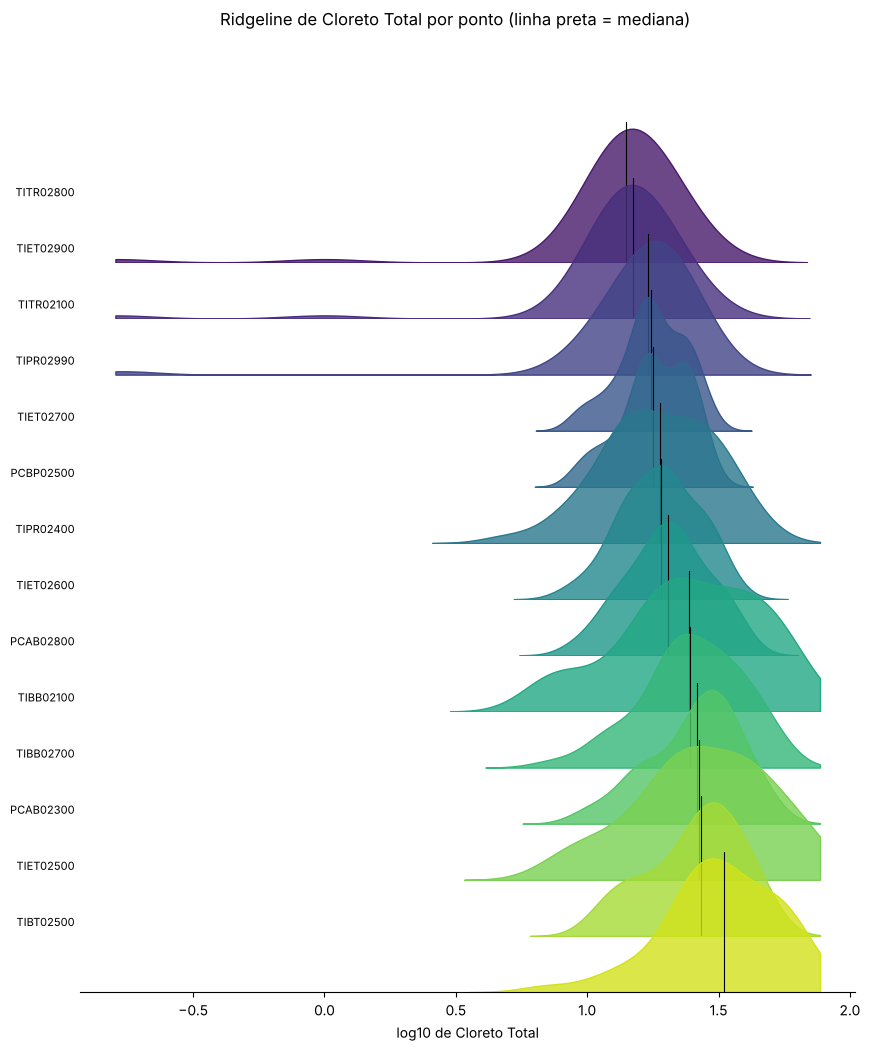

In [8]:
for coluna in colunas_obrigatorias:
    ridgelines(coluna)

In [9]:
# 1. Regra do IQR (Tukey) --- a mesma lógica do boxplot, mas numérica em vez de visual
def outliers_iqr(coluna):
    q1 = dataset[coluna].quantile(0.25)
    q3 = dataset[coluna].quantile(0.75)
    iqr = q3 - q1
    limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return dataset[(dataset[coluna] < limite_inf) | (dataset[coluna] > limite_sup)]

contagem_outliers_iqr = pd.Series({c: len(outliers_iqr(c)) for c in colunas_quantitativas})
contagem_outliers_iqr = contagem_outliers_iqr.sort_values(ascending=False)
print(contagem_outliers_iqr)

Alumínio Dissolvido                        195
Escherichia coli**                         145
Níquel Total                               144
Nitrogênio Amoniacal                       128
Ferro Total                                107
Alumínio Total                              96
Turbidez                                    88
Feofitina-a                                 68
Nitrogênio Kjeldahl                         61
Fluoreto Total                              57
Clorofila-a                                 50
DBO (5, 20)                                 47
Fósforo Total                               46
Subst. Tensoat. reagem c/ Azul Metileno     44
Condutividade                               42
Cloreto Total                               40
Nitrogênio-Nitrato                          37
Sulfato Total                               37
Bário Total                                 36
Nitrogênio-Nitrito                          36
Sódio                                       34
Carbono Orgân

In [10]:
# 2. IQR por ponto, em log --- o IQR global acima mistura pontos com linhas de base
# bem diferentes; aqui cada ponto é comparado só com ele mesmo. Não usamos z-score
# porque ele pressupõe distribuição ~normal, e a maioria dos grupos (variável x ponto)
# não é normal nem em log. O IQR não faz essa suposição. Obs.: valores censurados ('<')
# foram mantidos (ver comentário na carga dos dados), então variáveis com muitos deles
# (Mercúrio, Cádmio, Cobre Dissolvido) têm contagens pouco confiáveis.
def outliers_iqr_log_por_ponto(coluna):
    dados = dataset[dataset[coluna] > 0][["Ponto", "Data", coluna]].dropna().copy()
    dados["log_valor"] = np.log10(dados[coluna])
    grupo = dados.groupby("Ponto")["log_valor"]
    q1, q3 = grupo.transform(lambda s: s.quantile(0.25)), grupo.transform(lambda s: s.quantile(0.75))
    iqr = q3 - q1
    return dados[(dados["log_valor"] < q1 - 1.5 * iqr) | (dados["log_valor"] > q3 + 1.5 * iqr)]

contagem_outliers_ponto = pd.Series({c: len(outliers_iqr_log_por_ponto(c)) for c in colunas_quantitativas})
contagem_outliers_ponto = contagem_outliers_ponto.sort_values(ascending=False)
print(contagem_outliers_ponto)

Mercúrio Total                             103
Nitrogênio Amoniacal                        94
Subst. Tensoat. reagem c/ Azul Metileno     62
Cádmio Total                                61
Ferro Dissolvido                            55
Cobre Dissolvido                            54
Escherichia coli**                          42
Cobre Total                                 39
Fósforo-Ortofosfato                         38
Magnésio Total                              37
Bário Total                                 34
Carbono Orgânico Total                      34
Nitrogênio Kjeldahl                         31
DBO (5, 20)                                 28
Oxigênio Dissolvido                         25
Ferro Total                                 25
Fluoreto Total                              24
pH                                          24
Alumínio Dissolvido                         23
Sólido Total                                22
Nitrogênio-Nitrito                          22
Alumínio Tota

In [11]:
# "sniff test" - checa casos logicamente impossiveis
limites_fisicos = {
    "pH": (0, 14),
    "Temperatura da Água": (0, 40),
}

print("Valores fora do limite físico plausível:")
for coluna, (minimo, maximo) in limites_fisicos.items():
    fora = dataset[(dataset[coluna] < minimo) | (dataset[coluna] > maximo)]
    print(f"{coluna}: {len(fora)} fora de [{minimo}, {maximo}]")

print("\nConcentrações negativas (fisicamente impossível):")
colunas_concentracao = [c for c in colunas_quantitativas if c not in limites_fisicos]
for coluna in colunas_concentracao:
    negativos = dataset[dataset[coluna] < 0]
    if len(negativos) > 0:
        print(f"{coluna}: {len(negativos)} valores negativos")

Valores fora do limite físico plausível:
pH: 0 fora de [0, 14]
Temperatura da Água: 0 fora de [0, 40]

Concentrações negativas (fisicamente impossível):
